In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
def _3d_lidar_points(PATH):
    raw = np.fromfile(PATH, dtype=np.float32)

    # reshape to (x,y,z) and internsity
    lidar_points = raw.reshape(-1,4)

    xyz = lidar_points[:, :3]
    intensity = lidar_points[:, -1]

    return xyz, intensity

xyz, intensity = _3d_lidar_points(PATH = "../data/KITTI/training/velodyne/000000.bin")
xyz

array([[ 1.8324e+01,  4.9000e-02,  8.2900e-01],
       [ 1.8344e+01,  1.0600e-01,  8.2900e-01],
       [ 5.1299e+01,  5.0500e-01,  1.9440e+00],
       ...,
       [ 3.7180e+00, -1.4060e+00, -1.7370e+00],
       [ 3.7140e+00, -1.3910e+00, -1.7330e+00],
       [ 3.9670e+00, -1.4740e+00, -1.8570e+00]],
      shape=(115384, 3), dtype=float32)

In [22]:
def transformation_matrices(PATH):
    with open(PATH) as f:
        lines = f.readlines()

    line = []
    for i in range(0, len(lines)-1):
        line.append(lines[i])

    p0 = line[0].strip().split()[1:]
    p1 = line[1].strip().split()[1:]
    p2 = line[2].strip().split()[1:]
    p3 = line[3].strip().split()[1:]
    r0_rect = line[4].strip().split()[1:]
    tr_velo_to_cam = line[5].strip().split()[1:]
    tr_imu_to_velo = line[6].strip().split()[1:]

    # velo to cam- first tranformation
    tr_velo_to_cam = np.array(tr_velo_to_cam, dtype=np.float32).reshape(3, 4)

    # cam to rectified cam- second transformation
    r0_rect = np.array(r0_rect, dtype=np.float32).reshape(3, 3)

    # to 2d image- prjection
    p2 = np.array(p2, dtype=np.float32).reshape(3, 4)

    return tr_velo_to_cam, r0_rect, p2

tr_velo_to_cam, r0_rect, p2 = transformation_matrices(PATH = "../data/KITTI/training/calib/000000.txt")
print("P2:\n", p2)
print("\nR0_rect:\n", r0_rect)
print("\nT_velo_cam:\n", tr_velo_to_cam)

P2:
 [[ 7.070493e+02  0.000000e+00  6.040814e+02  4.575831e+01]
 [ 0.000000e+00  7.070493e+02  1.805066e+02 -3.454157e-01]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  4.981016e-03]]

R0_rect:
 [[ 0.9999128   0.01009263 -0.00851193]
 [-0.01012729  0.9999406  -0.00403767]
 [ 0.00847067  0.00412352  0.9999556 ]]

T_velo_cam:
 [[ 0.00692796 -0.9999722  -0.00275783 -0.02457729]
 [-0.00116298  0.00274984 -0.9999955  -0.06127237]
 [ 0.9999753   0.00693114 -0.0011439  -0.3321029 ]]


In [23]:
def transformation_to_rectified(xyz, tr_velo_to_cam, r0_rect):

    # Add homogeneous coordinate
    xyz_homogeneous = np.hstack([xyz, np.ones((xyz.shape[0], 1))])

    # LiDAR to camera
    camera_xyz = (tr_velo_to_cam @ xyz_homogeneous.T).T

    # Camera to rectified camera
    rectified_xyz = (r0_rect @ camera_xyz.T).T

    return rectified_xyz

rectified_xyz = transformation_to_rectified(xyz, tr_velo_to_cam, r0_rect)

In [24]:
def projection(rectified_xyz, p2):

    # Add homogeneous coordinate
    rectified_xyz_homogeneous = np.hstack([rectified_xyz, np.ones((rectified_xyz.shape[0], 1))])

    # Project 3D points into image coordinates
    image_coordinates = (p2 @ rectified_xyz_homogeneous.T).T

    # Perspective projection
    u = image_coordinates[:, 0] / image_coordinates[:, 2]
    v = image_coordinates[:, 1] / image_coordinates[:, 2]

    return u, v

All Functions combined

In [25]:
def _3d_lidar_points(PATH):
    raw = np.fromfile(PATH, dtype=np.float32)

    # reshape to (x,y,z) and internsity
    lidar_points = raw.reshape(-1,4)

    xyz = lidar_points[:, :3]
    intensity = lidar_points[:, -1]

    return xyz, intensity

xyz, intensity = _3d_lidar_points(PATH = "../data/KITTI/training/velodyne/000000.bin")

def transformation_matrices(PATH):
    with open(PATH) as f:
        lines = f.readlines()

    line = []
    for i in range(0, len(lines)-1):
        line.append(lines[i])

    p0 = line[0].strip().split()[1:]
    p1 = line[1].strip().split()[1:]
    p2 = line[2].strip().split()[1:]
    p3 = line[3].strip().split()[1:]
    r0_rect = line[4].strip().split()[1:]
    tr_velo_to_cam = line[5].strip().split()[1:]
    tr_imu_to_velo = line[6].strip().split()[1:]

    # velo to cam- first tranformation
    tr_velo_to_cam = np.array(tr_velo_to_cam, dtype=np.float32).reshape(3, 4)

    # cam to rectified cam- second transformation
    r0_rect = np.array(r0_rect, dtype=np.float32).reshape(3, 3)

    # to 2d image- prjection
    p2 = np.array(p2, dtype=np.float32).reshape(3, 4)

    return tr_velo_to_cam, r0_rect, p2

tr_velo_to_cam, r0_rect, p2 = transformation_matrices(PATH = "../data/KITTI/training/calib/000000.txt")


def transformation_to_rectified(xyz, tr_velo_to_cam, r0_rect):

    # Add homogeneous coordinate
    xyz_homogeneous = np.hstack([xyz, np.ones((xyz.shape[0], 1))])

    # LiDAR to camera
    camera_xyz = (tr_velo_to_cam @ xyz_homogeneous.T).T

    # Camera to rectified camera
    rectified_xyz = (r0_rect @ camera_xyz.T).T

    return rectified_xyz

rectified_xyz = transformation_to_rectified(xyz, tr_velo_to_cam, r0_rect)

def projection(rectified_xyz, p2):

    # Add homogeneous coordinate
    rectified_xyz_homogeneous = np.hstack([rectified_xyz, np.ones((rectified_xyz.shape[0], 1))])

    # Project 3D points into image coordinates
    image_coordinates = (p2 @ rectified_xyz_homogeneous.T).T

    # Perspective projection
    u = image_coordinates[:, 0] / image_coordinates[:, 2]
    v = image_coordinates[:, 1] / image_coordinates[:, 2]

    return u, v

Total LiDAR points: 115384
Points in front of camera: 60633


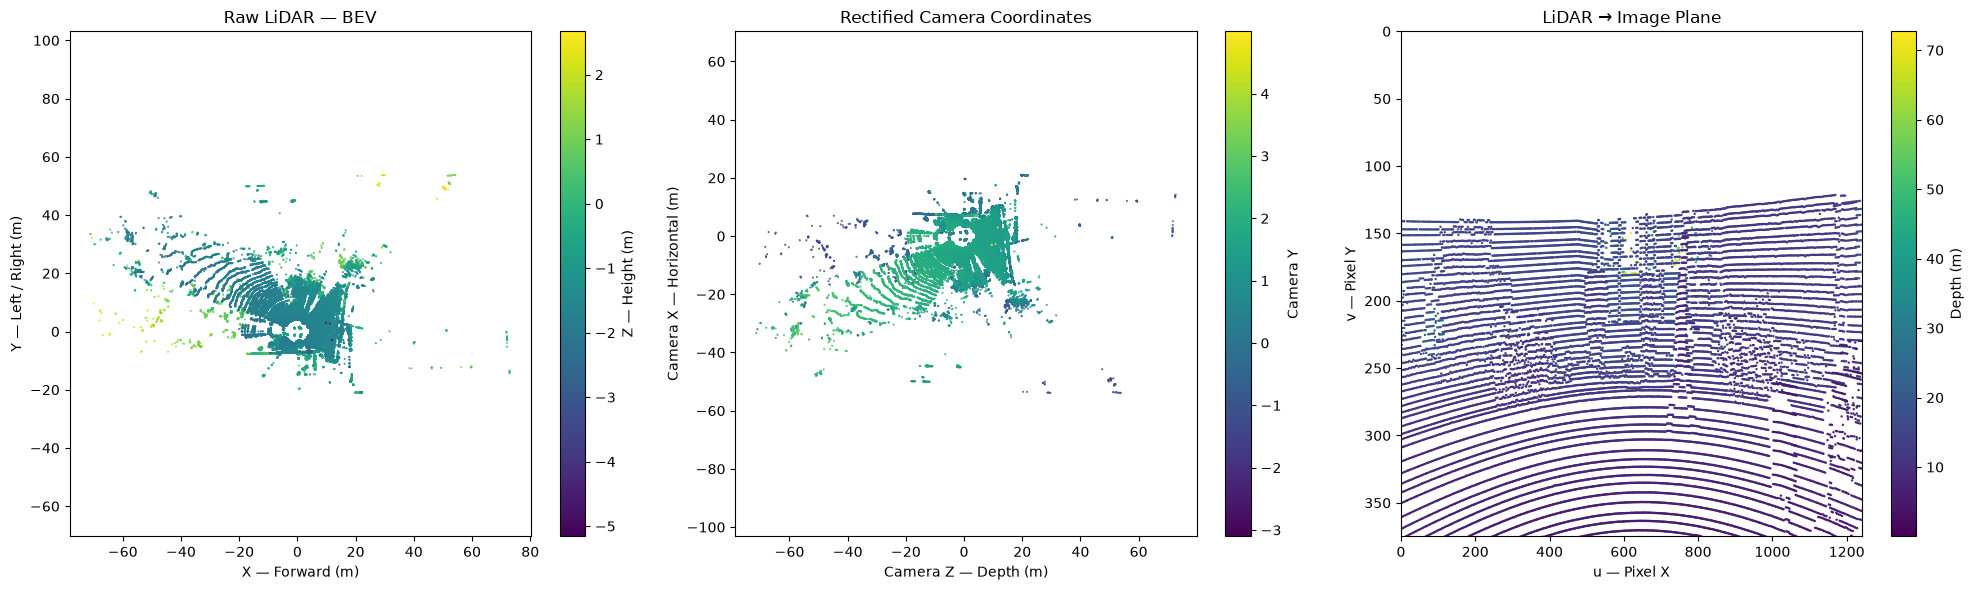

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Project LiDAR points
# ------------------------------------------------------------

u, v = projection(rectified_xyz, p2)

# ------------------------------------------------------------
# Keep only points in front of the camera
# ------------------------------------------------------------

valid_depth = rectified_xyz[:, 2] > 0

u_valid = u[valid_depth]
v_valid = v[valid_depth]
depth_valid = rectified_xyz[valid_depth, 2]

print("Total LiDAR points:", len(xyz))
print("Points in front of camera:", valid_depth.sum())


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 6)
)


# ============================================================
# 1. RAW LIDAR
# ============================================================

ax = axes[0]

scatter = ax.scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=xyz[:, 2],
    s=0.2
)

ax.set_title("Raw LiDAR — BEV")
ax.set_xlabel("X — Forward (m)")
ax.set_ylabel("Y — Left / Right (m)")
ax.axis("equal")

fig.colorbar(
    scatter,
    ax=ax,
    label="Z — Height (m)"
)


# ============================================================
# 2. RECTIFIED CAMERA COORDINATES
# ============================================================

ax = axes[1]

scatter = ax.scatter(
    rectified_xyz[:, 2],      # Z = depth
    rectified_xyz[:, 0],      # X = horizontal
    c=rectified_xyz[:, 1],    # Y = vertical
    s=0.2
)

ax.set_title("Rectified Camera Coordinates")
ax.set_xlabel("Camera Z — Depth (m)")
ax.set_ylabel("Camera X — Horizontal (m)")
ax.axis("equal")

fig.colorbar(
    scatter,
    ax=ax,
    label="Camera Y"
)


# ============================================================
# 3. PROJECTED IMAGE COORDINATES
# ============================================================

ax = axes[2]

scatter = ax.scatter(
    u_valid,
    v_valid,
    c=depth_valid,
    s=0.5
)

ax.set_title("LiDAR → Image Plane")
ax.set_xlabel("u — Pixel X")
ax.set_ylabel("v — Pixel Y")

# Approximate KITTI image dimensions
ax.set_xlim(0, 1242)
ax.set_ylim(375, 0)

fig.colorbar(
    scatter,
    ax=ax,
    label="Depth (m)"
)


plt.tight_layout()
plt.show()